# COSMO-CLM |q| distribution (physical vs normalized)

Compute a **global |q| distribution** over the full archive: every `metadata.csv` row × every grid pixel (streaming histogram; no disk output).

- **Physical**: raw Kelvin fields
- **Normalized**: `(T - mean) / std` (CMCC, same as LMM training) — **use this for training masks / thresholds**
- **Flux**: training-aligned (`grad_scalar=1`, same as `TemperatureFieldLosses`)
- **`MAX_SAMPLES=0`** (default): all ~184k timesteps. Use `MAX_SAMPLES=100` only for a quick test.
- Summary percentiles pool **all pixels and all timesteps** (not per-slice medians).

In [1]:
import io
import os
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import zstandard
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('notebooks') if Path('notebooks').exists() else NOTEBOOK_DIR
REPO_ROOT = (NOTEBOOK_DIR / '..').resolve()
sys.path.insert(0, str(REPO_ROOT))

from utils.temperature_normalization import (
    COSMO_SOURCE,
    default_normalization_pickle,
    load_norm_stats,
    normalize_temperature,
    norm_stats_summary,
)

LDM_DATA_ROOT = Path(os.environ.get('LDM_DATA_ROOT', REPO_ROOT / 'LDM-downscaling/full_Dataset')).resolve()
MAX_SAMPLES = int(os.environ.get('MAX_SAMPLES', '0'))  # 0 = all metadata rows
NUM_WORKERS = int(os.environ.get('NUM_WORKERS', '8'))
DX_HIGH, DY_HIGH = 2000.0, -2000.0
PLOT_VAR = '2mT'
HIST_LO, HIST_HI, HIST_BINS = 1e-30, 1e-8, 200

print('Data:', LDM_DATA_ROOT)
print('MAX_SAMPLES:', MAX_SAMPLES or 'all', ' NUM_WORKERS:', NUM_WORKERS)

Data: /mnt/data/chuongtnd/LDM-downscaling/full_Dataset
MAX_SAMPLES: all  NUM_WORKERS: 8


In [2]:
def load_high_2mT_kelvin(dataset_dir: Path, files_path_high: str, hour: int) -> np.ndarray:
    path = dataset_dir / files_path_high.lstrip('./')
    path = Path(str(path).replace('_high.pt.zst', '_high_2mT.pt.zst'))
    with path.open('rb') as f:
        raw = zstandard.ZstdDecompressor().decompress(f.read())
    data = torch.load(io.BytesIO(raw), map_location='cpu', weights_only=False)
    hour_data = data[int(hour)]
    t = hour_data['2mT'] if isinstance(hour_data, dict) else hour_data
    return np.asarray(t, dtype=np.float32)


def compute_flux_q_mag(T: np.ndarray, *, dx: float, dy: float) -> np.ndarray:
    T = np.asarray(T, dtype=np.float64)
    H, W = T.shape
    dTdx = np.zeros_like(T)
    dTdy = np.zeros_like(T)
    if W > 2:
        dTdx[:, 1:-1] = (T[:, 2:] - T[:, :-2]) / (2.0 * dx)
    if H > 2:
        dTdy[1:-1, :] = (T[2:, :] - T[:-2, :]) / (2.0 * dy)
    if W > 1:
        dTdx[:, 0] = (T[:, 1] - T[:, 0]) / dx
        dTdx[:, -1] = (T[:, -1] - T[:, -2]) / dx
    if H > 1:
        dTdy[0, :] = (T[1, :] - T[0, :]) / dy
        dTdy[-1, :] = (T[-1, :] - T[-2, :]) / dy
    gx, gy = dTdx, dTdy
    qx = -((gx * gx) * gx + (gx * gy) * gy)
    qy = -((gx * gy) * gx + (gy * gy) * gy)
    return np.hypot(qx, qy).astype(np.float32)


def make_log_bins():
    return np.logspace(np.log10(HIST_LO), np.log10(HIST_HI), HIST_BINS + 1)


def hist_add(counts, bin_edges, values):
    v = np.asarray(values, dtype=np.float64).ravel()
    v = v[np.isfinite(v) & (v > 0)]
    if v.size:
        counts += np.histogram(v, bins=bin_edges)[0].astype(np.int64)


def summary_from_hist(counts, bin_edges, label, *, n_zero, n_pixels):
    cdf = np.cumsum(counts).astype(np.float64)
    total = cdf[-1] if cdf.size else 0.0
    centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    if total <= 0:
        return {'space': label, 'min': 0, 'p50': 0, 'p90': 0, 'p99': 0, 'p99.9': 0, 'max': 0,
                'frac_==0': float(n_zero / max(n_pixels, 1)), 'n_pixels': n_pixels}
    out = {'space': label, 'frac_==0': float(n_zero / max(n_pixels, 1)), 'n_pixels': n_pixels}
    for name, p in zip(('p50', 'p90', 'p99', 'p99.9'), (50, 90, 99, 99.9)):
        t = p / 100.0 * total
        idx = min(max(int(np.searchsorted(cdf, t, side='left')), 0), len(centers) - 1)
        out[name] = float(centers[idx])
    pos = counts > 0
    out['min'] = float(bin_edges[:-1][np.argmax(pos)]) if pos.any() else 0.0
    out['max'] = float(bin_edges[1:][::-1][np.argmax(counts[::-1] > 0)]) if pos.any() else 0.0
    return out

In [3]:
meta = pd.read_csv(LDM_DATA_ROOT / 'metadata.csv', parse_dates=['ref_time'])
if MAX_SAMPLES > 0:
    meta = meta.iloc[:MAX_SAMPLES]
norm_values = load_norm_stats(default_normalization_pickle(REPO_ROOT))
display(pd.DataFrame([norm_stats_summary(norm_values, PLOT_VAR, COSMO_SOURCE)]))
print(f'Timesteps to process: {len(meta)}')

,source,variable,mean,std
0,CMCC,2mT,288.71225,8.29213


Timesteps to process: 184104


In [4]:
_G = {}


def _pool_init(dataset_dir, norm_values, dx, dy):
    _G['dataset_dir'] = Path(dataset_dir)
    _G['norm_values'] = norm_values
    _G['dx'], _G['dy'] = dx, dy
    _G['bin_edges'] = make_log_bins()


def _process_row(row):
    be = _G['bin_edges']
    hr = np.zeros(len(be) - 1, dtype=np.int64)
    hn = np.zeros(len(be) - 1, dtype=np.int64)
    try:
        T = load_high_2mT_kelvin(_G['dataset_dir'], row['files_path_high'], int(row['hour']))
        Tn = normalize_temperature(T, variable=PLOT_VAR, source=COSMO_SOURCE, norm_values=_G['norm_values'])
        qmr = compute_flux_q_mag(T, dx=_G['dx'], dy=_G['dy'])
        qmn = compute_flux_q_mag(Tn, dx=_G['dx'], dy=_G['dy'])
        hist_add(hr, be, qmr)
        hist_add(hn, be, qmn)
        return hr, hn, int(np.sum(qmr == 0)), int(np.sum(qmn == 0)), int(qmr.size), None
    except Exception as exc:
        return hr, hn, 0, 0, 0, str(exc)


bin_edges = make_log_bins()
hist_raw = np.zeros(len(bin_edges) - 1, dtype=np.int64)
hist_norm = np.zeros(len(bin_edges) - 1, dtype=np.int64)
n_zero_raw = n_zero_norm = n_pixels = 0
errors = []
rows = meta.to_dict(orient='records')
n_workers = max(1, min(NUM_WORKERS, len(rows)))

with ProcessPoolExecutor(
    max_workers=n_workers,
    initializer=_pool_init,
    initargs=(str(LDM_DATA_ROOT), norm_values, DX_HIGH, DY_HIGH),
) as pool:
    futs = [pool.submit(_process_row, r) for r in rows]
    for i, fut in enumerate(as_completed(futs), 1):
        hr, hn, zr, zn, npix, err = fut.result()
        hist_raw += hr
        hist_norm += hn
        n_zero_raw += zr
        n_zero_norm += zn
        n_pixels += npix
        if err:
            errors.append(err)
        if i % 500 == 0 or i == len(rows):
            print(f'progress {i}/{len(rows)}')

if errors:
    print(f'errors: {len(errors)} (first: {errors[0]})')

summary_df = pd.DataFrame([
    summary_from_hist(hist_raw, bin_edges, 'physical [K flux units]', n_zero=n_zero_raw, n_pixels=n_pixels),
    summary_from_hist(hist_norm, bin_edges, 'normalized (training)', n_zero=n_zero_norm, n_pixels=n_pixels),
])
centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
print('|q| distribution (all processed timesteps):')
display(summary_df)

print('Example training mask thresholds (normalized |q|, global percentiles):')
for p in (1, 5, 10, 25):
    t = p / 100.0 * max(hist_norm.sum(), 1)
    cdf = np.cumsum(hist_norm)
    idx = min(int(np.searchsorted(cdf, t, side='left')), len(centers) - 1)
    print(f'  skip if |q_norm| < p{p} ~ {centers[idx]:.6e}')

progress 500/184104
progress 1000/184104
progress 1500/184104
progress 2000/184104
progress 2500/184104
progress 3000/184104
progress 3500/184104
progress 4000/184104
progress 4500/184104
progress 5000/184104
progress 5500/184104
progress 6000/184104
progress 6500/184104
progress 7000/184104
progress 7500/184104
progress 8000/184104
progress 8500/184104
progress 9000/184104
progress 9500/184104
progress 10000/184104
progress 10500/184104
progress 11000/184104
progress 11500/184104
progress 12000/184104
progress 12500/184104
progress 13000/184104
progress 13500/184104
progress 14000/184104
progress 14500/184104
progress 15000/184104
progress 15500/184104
progress 16000/184104
progress 16500/184104
progress 17000/184104
progress 17500/184104
progress 18000/184104
progress 18500/184104
progress 19000/184104
progress 19500/184104
progress 20000/184104
progress 20500/184104
progress 21000/184104
progress 21500/184104
progress 22000/184104
progress 22500/184104
progress 23000/184104
progress

,space,frac_==0,n_pixels,p50,p90,p99,p99.9,min,max
0,physical [K flux units],0.001316,71261503488,2.917427e-16,2.722701e-13,4.415704e-12,2.018366e-11,9.549926e-29,2.187762e-09
1,normalized (training),0.001316,71261503488,5.188000e-19,4.841724e-16,7.852356e-15,2.786121e-14,1.000000e-30,3.890451e-12


Example training mask thresholds (normalized |q|, global percentiles):
  skip if |q_norm| < p1 ~ 2.660725e-23
  skip if |q_norm| < p5 ~ 2.600160e-22
  skip if |q_norm| < p10 ~ 9.225714e-22
  skip if |q_norm| < p25 ~ 9.015711e-21


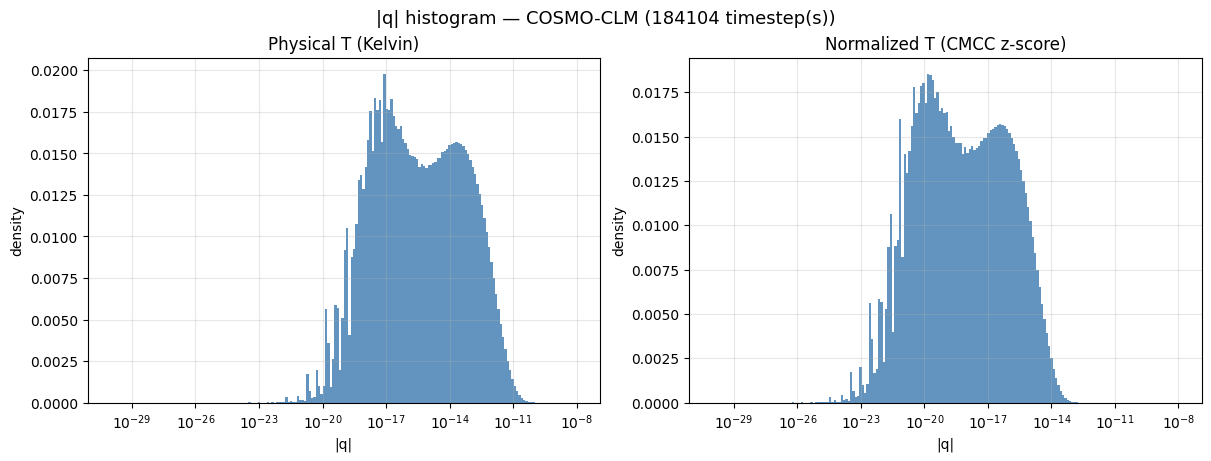

In [5]:
dens_raw = hist_raw / max(hist_raw.sum(), 1)
dens_norm = hist_norm / max(hist_norm.sum(), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
fig.suptitle(f'|q| histogram — COSMO-CLM ({len(meta)} timestep(s))', fontsize=13)
for ax, dens, title in zip(
    axes,
    [dens_raw, dens_norm],
    ['Physical T (Kelvin)', 'Normalized T (CMCC z-score)'],
):
    ax.stairs(dens, bin_edges, fill=True, color='steelblue', alpha=0.85)
    ax.set_xscale('log')
    ax.set_xlabel('|q|')
    ax.set_ylabel('density')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.show()

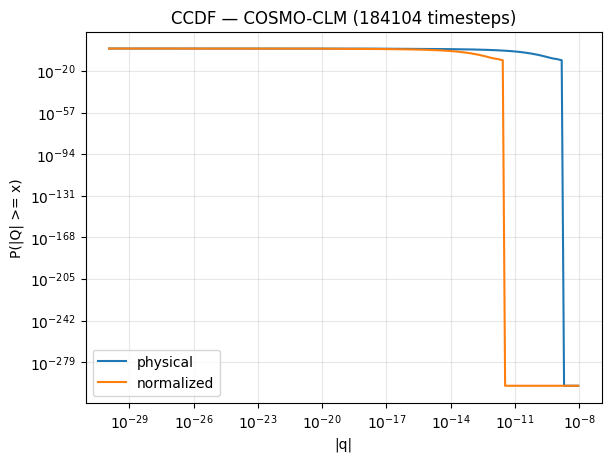

In [6]:
fig2, ax2 = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
for counts, label, c in [(hist_raw, 'physical', 'C0'), (hist_norm, 'normalized', 'C1')]:
    ccdf = 1.0 - np.cumsum(counts) / max(counts.sum(), 1)
    ax2.loglog(centers, ccdf + 1e-300, label=label, color=c, linewidth=1.5)
ax2.set_xlabel('|q|')
ax2.set_ylabel('P(|Q| >= x)')
ax2.set_title(f'CCDF — COSMO-CLM ({len(meta)} timesteps)')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)
plt.show()